# Laboratorium 3 — interpretowalność modelu bez SHAP

Krótki notebook dla chętnych pokazujący prostszą i stabilną alternatywę dla `SHAP`: `permutation importance` oraz `partial dependence plots` ze `scikit-learn`.


## Przydatne materiały
- `permutation_importance`: https://scikit-learn.org/stable/modules/permutation_importance.html
- `PartialDependenceDisplay`: https://scikit-learn.org/stable/modules/generated/sklearn.inspection.PartialDependenceDisplay.html
- Ta wersja nie wymaga `shap` i powinna działać w obecnym środowisku `uv`.


## Jak uruchomić alternatywne środowisko dla prawdziwego `SHAP`
Jeżeli chcesz mimo wszystko uruchomić klasyczny przykład z `SHAP`, najbezpieczniej zrobić to w osobnym środowisku, poza podstawowym `uv` dla tego laboratorium.

Przykład w terminalu:

```bash
python3 -m venv .venv-shap
source .venv-shap/bin/activate
python -m pip install --upgrade pip
python -m pip install "setuptools<81" shap jupyterlab scikit-learn pandas matplotlib
python -m ipykernel install --user --name lab3-shap --display-name "Python (lab3-shap)"
jupyter lab
```

Po uruchomieniu Jupyter wybierz kernel `Python (lab3-shap)` dla notebooka.

Uwaga: nawet to środowisko może nie zadziałać na każdym macOS/Python 3.10, dlatego domyślnie w tym laboratorium używamy stabilniejszej alternatywy opartej o `scikit-learn`.


In [33]:
import warnings
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import load_digits
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")


In [34]:
digits = load_digits(as_frame=True)
digits_df = digits.frame.sample(n=500, random_state=42)
X = digits_df.drop(columns=['target'])
y = digits_df['target'].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

model = RandomForestClassifier(random_state=42, n_estimators=100)
model.fit(X_train, y_train)
model.score(X_test, y_test)


0.96

In [35]:
result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)

importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance_mean': result.importances_mean,
    'importance_std': result.importances_std,
}).sort_values("importance_mean", ascending=False)

importance_df.head(10)


,feature,importance_mean,importance_std
21,pixel_2_5,0.0488,0.020999
26,pixel_3_2,0.0240,0.013387
42,pixel_5_2,0.0200,0.008944
43,pixel_5_3,0.0192,0.011973
19,pixel_2_3,0.0128,0.007332
33,pixel_4_1,0.0128,0.007332
54,pixel_6_6,0.0112,0.006400
27,pixel_3_3,0.0104,0.005122
13,pixel_1_5,0.0104,0.008800
28,pixel_3_4,0.0096,0.005987


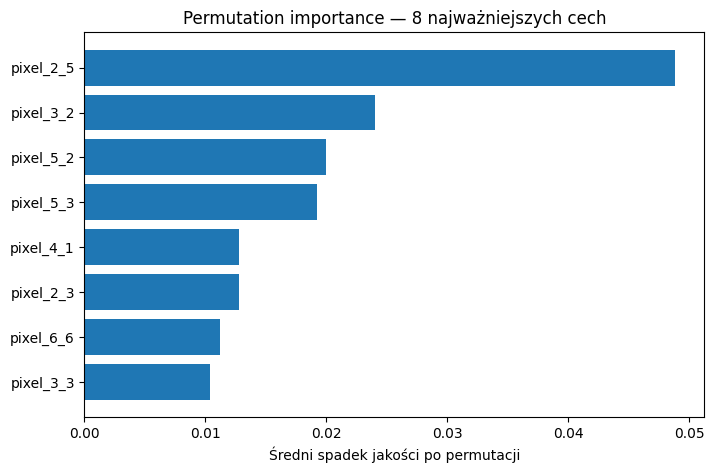

In [36]:
top_features = importance_df.head(8).sort_values("importance_mean")
plt.figure(figsize=(8, 5))
plt.barh(top_features["feature"].astype(str), top_features["importance_mean"])
plt.title("Permutation importance — 8 najważniejszych cech")
plt.xlabel("Średni spadek jakości po permutacji")
plt.show()


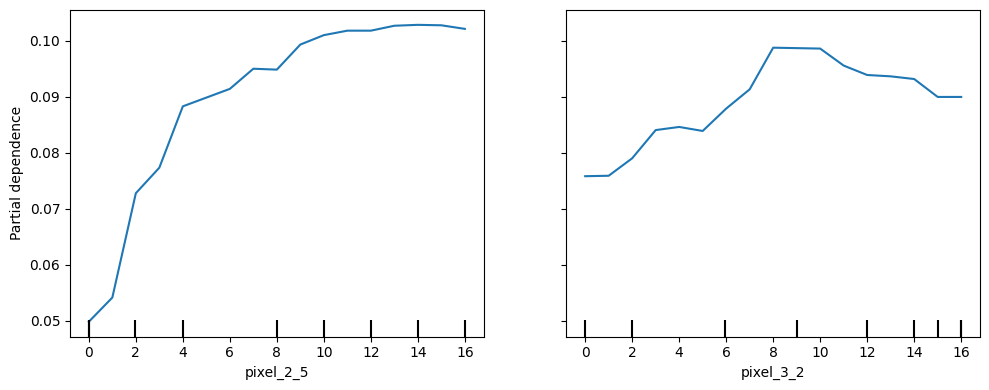

In [37]:
selected_features = importance_df.head(2)["feature"].tolist()
target_class = y_test.iloc[0]
fig, ax = plt.subplots(figsize=(10, 4))
PartialDependenceDisplay.from_estimator(
    model, X_test, features=selected_features, target=target_class, ax=ax
)
plt.tight_layout()


## Pytania do interpretacji
1. Które cechy model uznaje za najważniejsze?
2. Czy ranking ważności zgadza się z intuicją dla obrazów cyfr?
3. Jak różni się taka interpretacja od tego, co dawałby `SHAP`?
